In [173]:
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import LogLocator, ScalarFormatter, LogFormatter
import seaborn as sns
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

Text(0.5, 0, 'log($M_T$)')

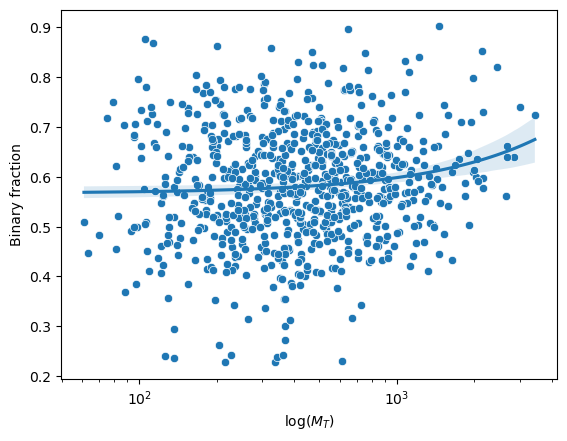

In [7]:
sns.regplot(data=df, x=df.mass_total, y='bin_frac', scatter=False, )
sns.scatterplot(data=df, x=df.mass_total, y='bin_frac')
plt.xscale('log')

plt.ylabel('Binary fraction')
plt.xlabel(r'log($M_T$)')


In [40]:
def calcula_sistemas(df, m, dm=1):
    ns = len(df[df.q==0])
    n_prim = len(df[(df.mass>m) & (df.mass<= m +dm) & (df.q>0)])
    n_sec = len(df[(df.comp_mass>m) & (df.comp_mass<= m +dm)])
    total = len(df[((df.mass>m) & (df.mass<= m +dm) )| ((df.comp_mass>m) & (df.comp_mass<= m +dm))])
    return ns, n_prim, n_sec, total

def calcula_P_prim(df, m, dm=1):
    total = len(df)
    N_prim = len(df[(df.mass>= m) & (df.mass<m+dm) & (df.comp_mass>0)])
    P_prim = N_prim/total
    q_prim = df[(df.mass>= m) & (df.mass<m+dm) & (df.comp_mass>0)].q.median()
    return P_prim, q_prim

def calcula_P_sec(df, m, dm=1):
    total = len(df)
    n_sec = len(df[(df.comp_mass>= m) & (df.comp_mass<m+dm) & (df.q>0)])
    P_sec = n_sec/total
    q_sec = df[(df.comp_mass>= m) & (df.comp_mass<m+dm) & (df.q>0)].q.median()
    return P_sec, q_sec

def calcula_P_BS(df,m, dm=1):
    n_prim = len(df[(df.mass>m) & (df.mass<= m +dm) & (df.q>0)])
    n_sec = len(df[(df.comp_mass>m) & (df.comp_mass<= m +dm)])
    total =len(df)
    P_BS = (n_prim+n_sec)/total
    q_BS = df[df.q>0].q.median()
    return P_BS, q_BS






def calcula_probabilidades(df, stat):
    m = 0
    x = []
    er_x = []
    P_prim_list = []
    P_sec_list = []
    P_BS_list = []
    n_stars = []
    qs = [[], [], []]  # [prim, sec, BS]

    while m < df.mass.max():
        
        if m<=1:
            dm = 0.1
        else:
            dm = 1
        mask = ((df.mass >= m) & (df.mass < m + dm)) | \
               ((df.comp_mass >= m) & (df.comp_mass < m + dm) & (df.q > 0))
        aux = df[mask]

        if len(aux) >= 100:
            primary_mass = aux[(aux.mass >= m) & (aux.mass < m + dm)][['mass', 'er_mass']]
            comp_mass = aux[(aux.comp_mass >= m) & (aux.comp_mass < m + dm)][['comp_mass', 'er_comp_mass']]

            pmemb = np.concatenate((
                aux[(aux.mass >= m) & (aux.mass < m + dm)]['Pmemb'],
                aux[(aux.comp_mass >= m) & (aux.comp_mass < m + dm)]['Pmemb']
            ))

            all_masses = np.concatenate((primary_mass.mass.values, comp_mass.comp_mass.values))
            er_all_masses = np.concatenate((primary_mass.er_mass.values, comp_mass.er_comp_mass.values))

            all_masses = unp.uarray(all_masses, er_all_masses)
            n_stars.append(len(all_masses))

            # Estatísticas de massa
            if stat == 'media':
                mean = unp.log10(all_masses).mean()
                x.append(unp.nominal_values(mean))
                er_x.append(unp.std_devs(mean))
            elif stat == 'ponderada':
                pesos = pmemb * (1 / (unp.std_devs(all_masses) + 1e-10)**2)
                mean = (all_masses * pesos).sum() / pesos.sum()
                x.append(unp.nominal_values(mean))
                er_x.append(unp.std_devs(mean))

            # Probabilidades e razões de massa
            P_prim, q_prim = calcula_P_prim(aux, m, dm)
            P_sec, q_sec = calcula_P_sec(aux, m, dm)
            P_BS, q_BS = calcula_P_BS(aux, m, dm)

            P_prim_list.append(P_prim)
            P_sec_list.append(P_sec)
            P_BS_list.append(P_BS)

            qs[0].append(q_prim)
            qs[1].append(q_sec)
            qs[2].append(q_BS)

        m += dm

    return (
        np.array(x),
        np.array(er_x),
        np.array(P_prim_list),
        np.array(P_sec_list),
        np.array(P_BS_list),
        n_stars,
        qs
    )


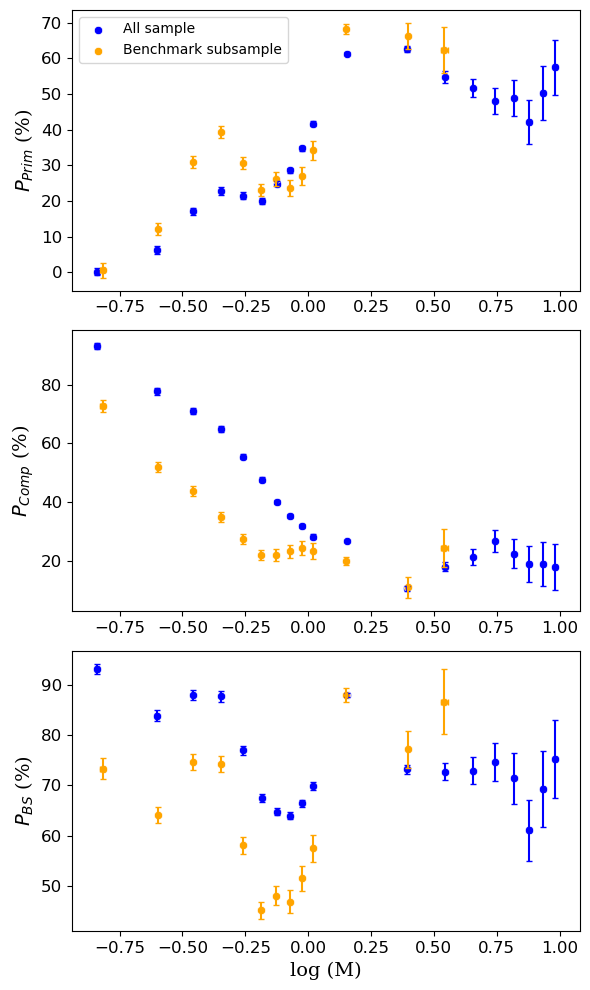

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter

samples = ['all', 'benchmark']
fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True)



for sample in samples:
    if sample == 'benchmark':
        aux = data.loc[benchmark_subsample.index]
        color = 'orange'
        label = 'Benchmark subsample'
    else:
        aux = data
        color = 'b'
        label = 'All sample'
        
    x, er_x, P_prim, P_sec, P_BS, n_stars, qs = calcula_probabilidades(aux, 'media')
    
    sns.scatterplot(x=x, y=P_prim*100, color=color, label=label, legend=True, ax=axs[0])
    sns.scatterplot(x=x, y=P_sec*100, color=color, legend=False, ax=axs[1])
    sns.scatterplot(x=x, y=P_BS*100, color=color, legend=False, ax=axs[2])
    
    err_y = 100 * np.sqrt(n_stars) / n_stars
    
    axs[0].errorbar(x, P_prim*100, xerr=er_x, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    axs[1].errorbar(x, P_sec*100, xerr=er_x, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    axs[2].errorbar(x, P_BS*100, xerr=er_x, yerr=err_y, fmt='none', ecolor=color, capsize=2)

# Rótulos dos eixos
axs[0].set_ylabel(r'$P_{Prim}$ (%)', fontdict=font)
axs[1].set_ylabel(r'$P_{Comp}$ (%)', fontdict=font)
axs[2].set_ylabel(r'$P_{BS}$ (%)', fontdict=font)
axs[2].set_xlabel(r'log (M)', fontdict=font)



# Aplica mesmo estilo aos três painéis
for ax in axs:
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)

plt.tight_layout()
plt.show()


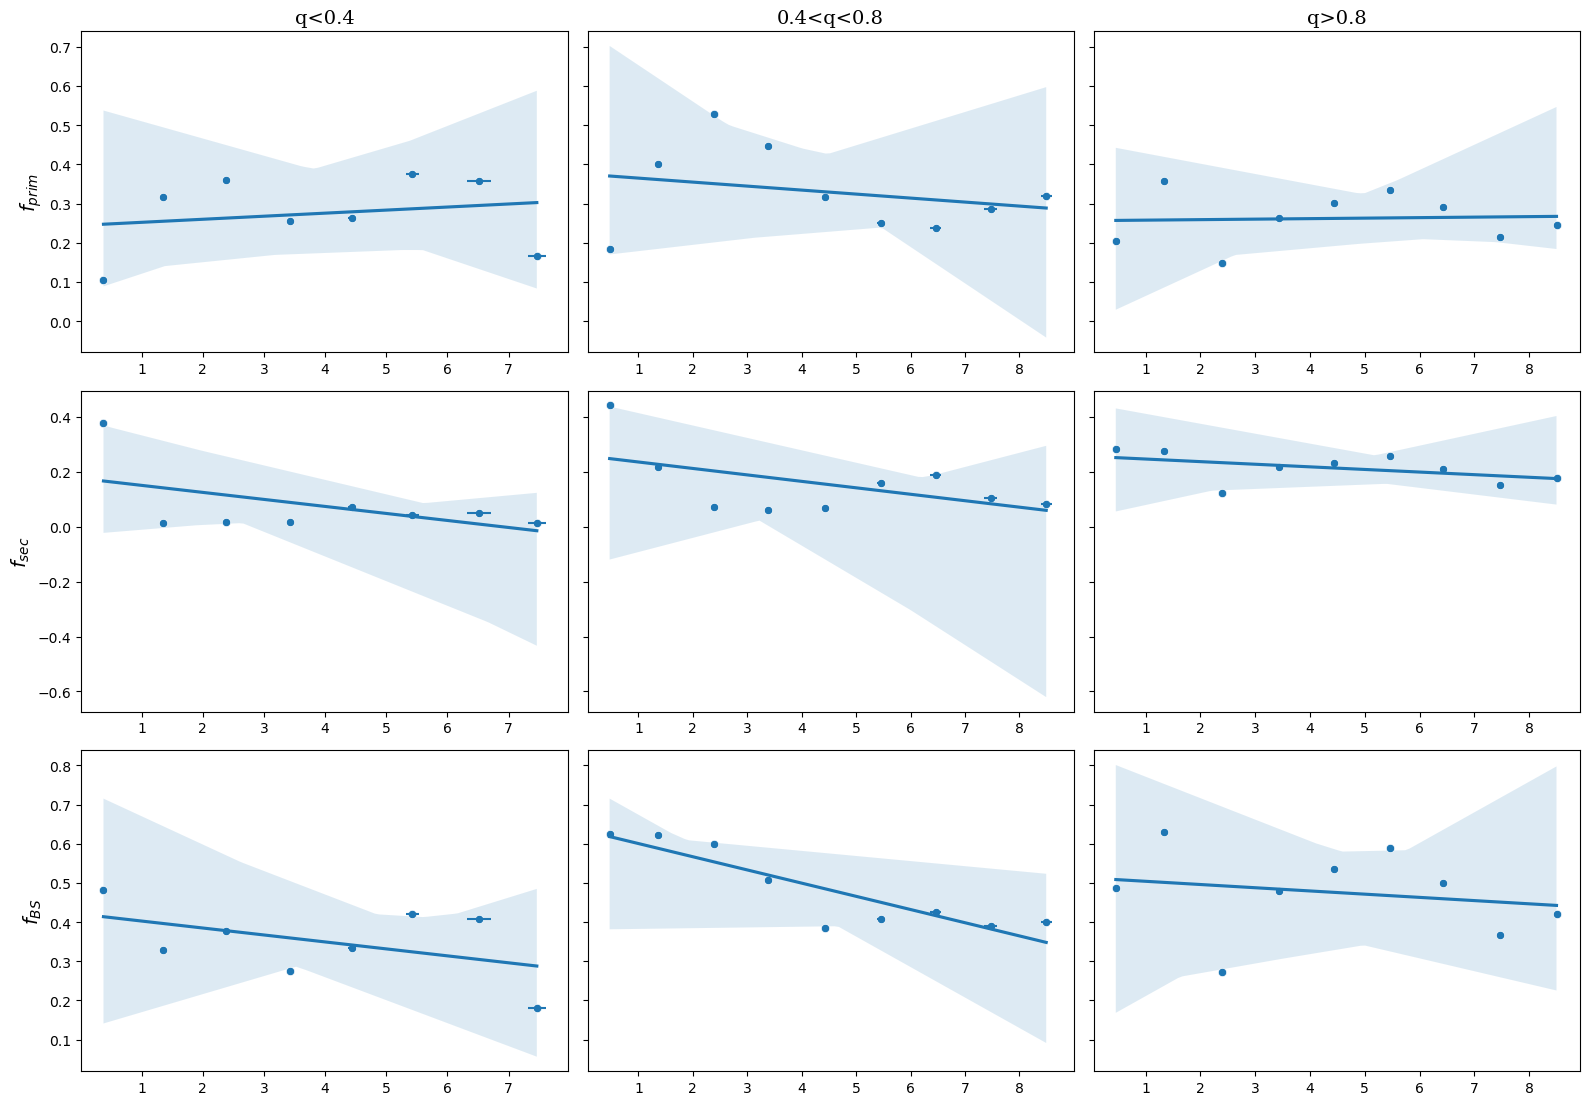

In [5]:
row = 3
col = 3

quantidades = [fb_prim, fb_sec, mf]
y_labels = [r'$f_{prim}$', r'$f_{sec}$', r'$f_{BS}$']
titles =['q<0.4', '0.4<q<0.8', 'q>0.8']
fig, axs = plt.subplots(row,col, figsize = (16,12), sharey='row',)

for i in range(0,row):
    for j in range(0, col):
        sns.regplot(x= x[j], y= np.array(quantidades[i][j])  ,ax=axs[i,j], scatter=False, ci=100)
        sns.scatterplot(x= x[j], y= np.array(quantidades[i][j])  ,ax=axs[i,j])
        axs[i,j].set_ylabel(y_labels[i], fontdict=font)
        axs[i,j].errorbar(x[j], np.array(quantidades[i][j]), fmt='none', xerr= er_x[j])
    
    axs[0,i].set_title(titles[i], fontdict=font)
plt.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig('dist_fb_por_massa_2.png',bbox_inches='tight', dpi=300)
plt.show()

In [117]:
c = 4 * np.pi / 3
V = c*df['rh']**3
density = df['n_members']/V
q_mean = []
for cluster in df.index:
    q_mean.append(data[data.q>0].loc[cluster, 'q'].mean())


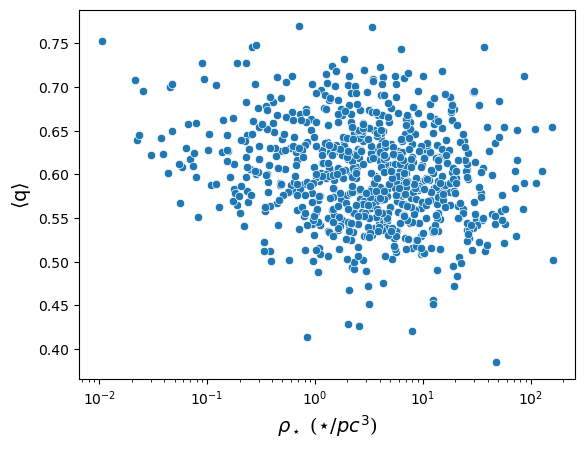

In [118]:
sns.scatterplot(x=density,y=q_mean)
plt.xscale('log')
plt.xlabel(r'$\rho_\star$ ($\star/pc^3$)', fontdict=font)
plt.ylabel(r"$\langle \mathrm{q} \rangle$", fontdict=font)

plt.show()

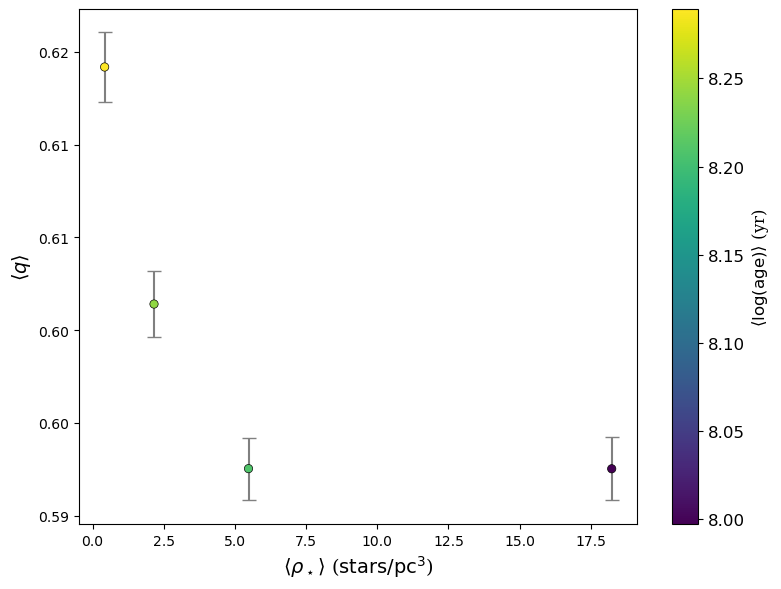

In [196]:
# Calcula a razão de massa média de binárias em aglomerados agrupados pela densidade estelar
# os dados foram separados em quartis de densidade 

aux = df.copy(deep=True)
aux['Density_Quartile'] = pd.qcut(aux['density'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
cluster_to_quartile = aux['Density_Quartile'].to_dict()

# Filtrar dados binários
binaries_data = data[data['q'] > 0].copy()
binaries_data['Density_Quartile'] = binaries_data.index.map(cluster_to_quartile)
binaries_data = binaries_data.dropna(subset=['Density_Quartile'])

# Calcula os valores medios de para cada quartil
mean_q = binaries_data.groupby('Density_Quartile')['q'].mean()
mean_age = aux.groupby('Density_Quartile')['age'].mean()
std_q = binaries_data.groupby('Density_Quartile')['q'].std()
count_q = binaries_data.groupby('Density_Quartile')['q'].count()
er_q = std_q / np.sqrt(count_q)
mean_density = aux.groupby('Density_Quartile')['density'].median()



plt.figure(figsize=(8, 6))

sns.scatterplot(x=mean_density, y=mean_q, hue=mean_age, palette=palette, edgecolor='k', zorder=3, legend=False)
plt.errorbar(mean_density.values, mean_q.values, yerr=er_q.values, fmt='none', capsize=5, c='gray', zorder=2)

plt.xlabel(r'$\langle \rho_\star \rangle$ ($\mathrm{stars/pc^3}$)', fontdict=font)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.ylabel(r'$\langle q \rangle$', fontdict=font)

norm = plt.Normalize(mean_age.min(), mean_age.max()) 
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label(r'$\langle \mathrm{log(age)} \rangle$ (yr)', fontdict=font_cb)
cbar.ax.tick_params(labelsize=labelsize) 
plt.tight_layout()
plt.show()


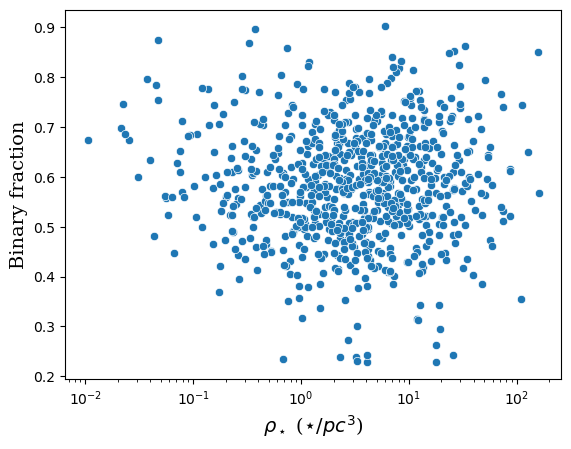

In [107]:
# Mesma ideia, só que agora pra fraçãod de binárias média

mean_fb = aux.groupby('Density_Quartile')['bin_frac'].mean()
mean_age = aux.groupby('Density_Quartile')['age'].mean()
std_fb = aux.groupby('Density_Quartile')['bin_frac'].std()
count_clusters = len(aux.groupby('Density_Quartile'))
er_fb = std_q / np.sqrt(count_clusters)
median_density = aux.groupby('Density_Quartile')['density'].median()

sns.scatterplot(x=density,y=df.bin_frac)
plt.xscale('log')
plt.xlabel(r'$\rho_\star$ ($\star/pc^3$)', fontdict=font)
plt.ylabel(r"Binary fraction", fontdict=font)

plt.show()

In [197]:
df.columns

Index(['RA_ICRS', 'DE_ICRS', 'dist', 'e_dist', 'age', 'e_age', 'Av', 'e_Av',
       'FeH', 'e_FeH', 'Nc', 'n_members', 'mass_total', 'e_mass_total',
       'alpha_high_int', 'alpha_high_er_int', 'alpha_low_int',
       'alpha_low_er_int', 'Mc_int', 'Mc_er_int', 'offset_int',
       'offset_er_int', 'rh', 'e_rh', 'stellar_dens', 'e_stellar_dens',
       't_relax', 'e_t_relax', 'tau', 'e_tau', 'bin_frac', 'e_bin_frac',
       'bin_frac_0.5', 'e_bin_frac_0.5', 'average_ratio', 'str_average_ratio',
       'segr_ratio', 'segr_ratio_std', 'mass_seg', 'mass_seg_pval', 'density'],
      dtype='object')